In [1]:
from pathlib import Path
from mutools.plotting import run, prism_schematic, use_style
import mutools.plotting as mp

# Configure once — applies everywhere
mp.saver.configure(fmt="pdf", dpi=300, rasterized=True, ytick_precision=2)

use_style("rootlike")
INPUT = Path('/Users/mueller/Projects/spineosc')
OUTPUT = Path('/Users/mueller/Projects/spineosc/figures')
TECHNOTE = Path('/Users/mueller/Projects/spineosc_technote/figures')
WRITE = True

In [2]:
def map_file(
    figure_directory: Path,
    out: Path,
    map: dict[str, str]
) -> None:
    """
    This function takes a `figure_directory`, an `out` directory, and a
    `map` of old filenames to new filenames. It renames the files in
    the `figure_directory` according to the `map` and saves them in the
    `out` directory. If a file in the `map` does not exist in the
    `figure_directory`, it prints a warning message.

    Parameters
    ----------
    figure_directory : Path
        The directory where the original figure files are located.
    out : Path
        The directory where the renamed figure files should be saved.
    map : dict[str, str]
        A dictionary mapping old filenames (keys) to new filenames
        (values). The old filenames should be relative to the
        `figure_directory`, and the new filenames should be relative to
        the `out` directory.

    Returns
    -------
    None.
    """
    for old, new in map.items():
        # We construct the full paths to the old and new files. The
        # `old_path` is the `figure_directory` + the `old` filename,
        # and the `new_path` is the `out` directory + the `new`
        # filename.
        old_path = out / old
        new_path = figure_directory / new

        # The `new_path` is some directory + filename, so we need to
        # make sure the directory exists before we can rename the file.
        new_path.parent.mkdir(parents=True, exist_ok=True)

        # Now we can rename the file if it exists. If it doesn't exist,
        # we print a warning message.
        if old_path.exists():
            old_path.rename(new_path)
            print(f"Renamed {old_path} to {new_path}")
        else:
            print(f"Warning: {old_path} does not exist and cannot be renamed to {new_path}")

Renamed /Users/mueller/Projects/spineosc/figures/hist_0_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_signal_bymode_sbnd.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_1_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_signal_bymode_icarus_run2.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_2_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_signal_bymode_icarus_run4.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_0_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/exclusive_ccqe_signal_bymode_sbnd.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_1_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/exclusive_ccqe_signal_bymode_icarus_run2.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_2_0_v3.0.0.pdf to /Users/mueller/Pr

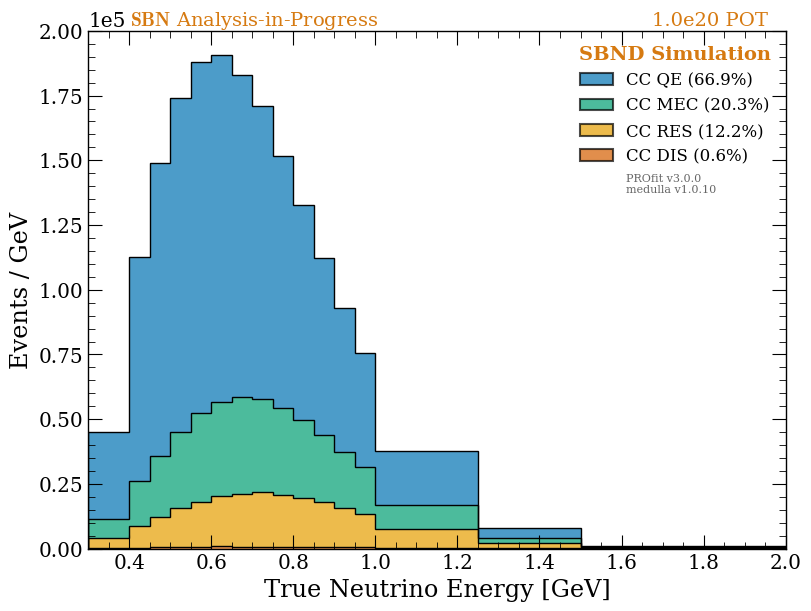

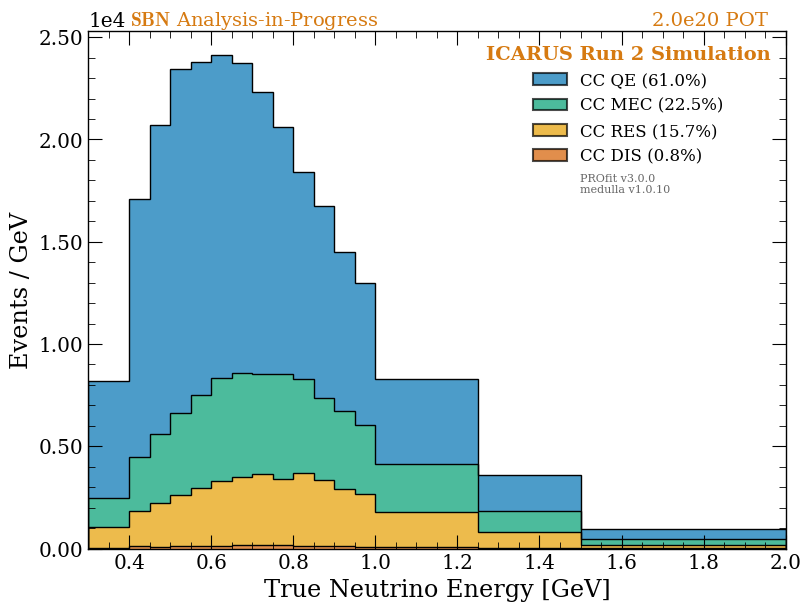

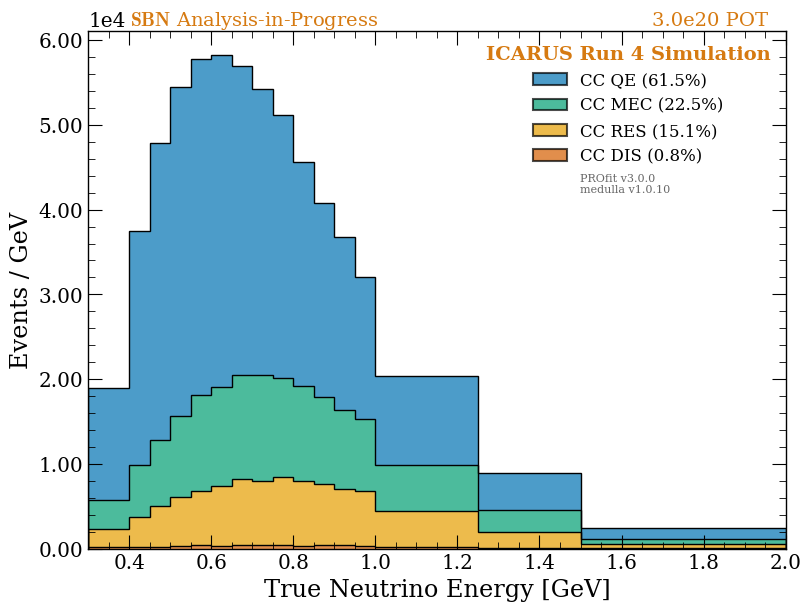

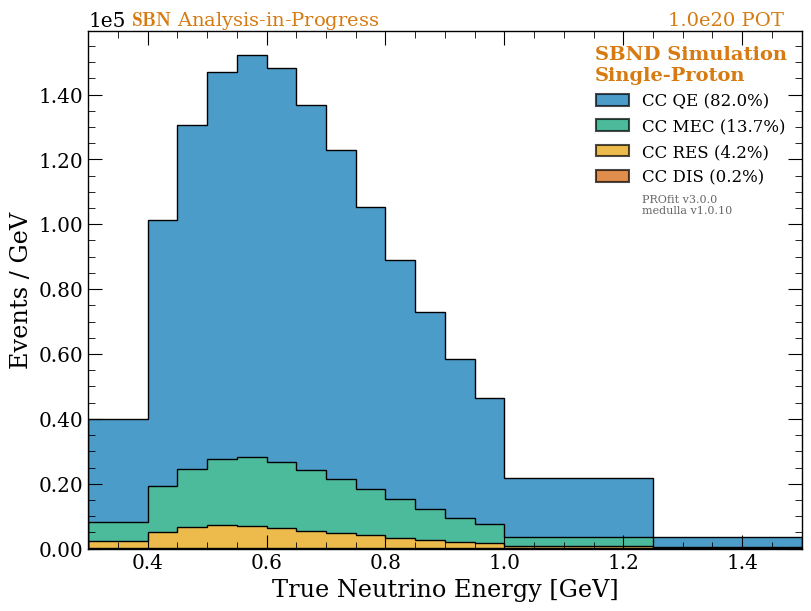

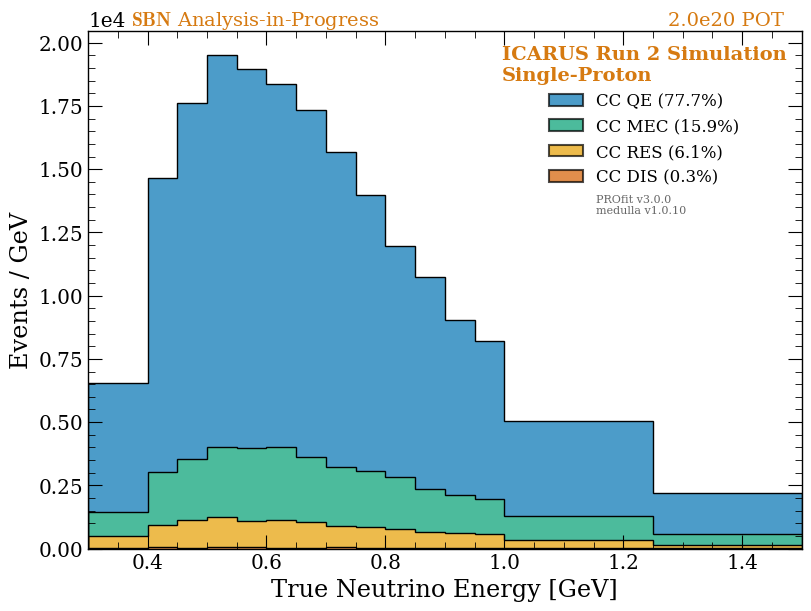

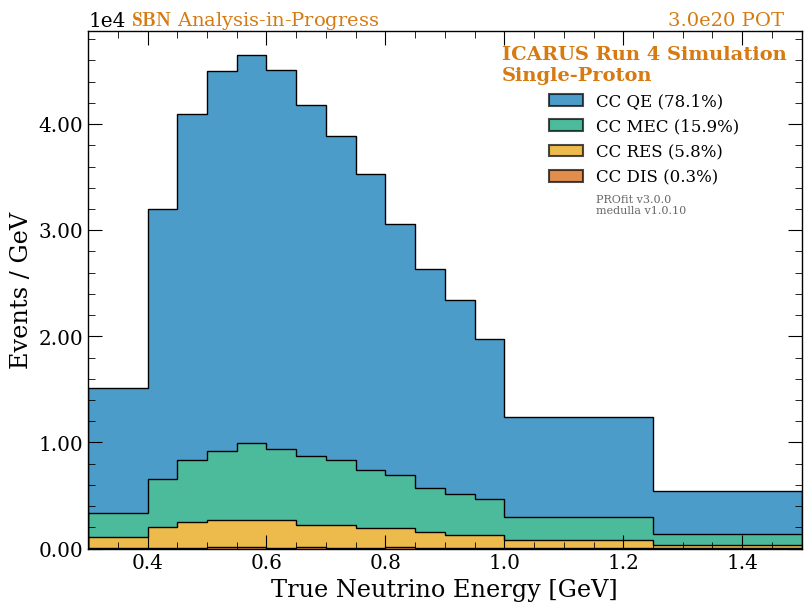

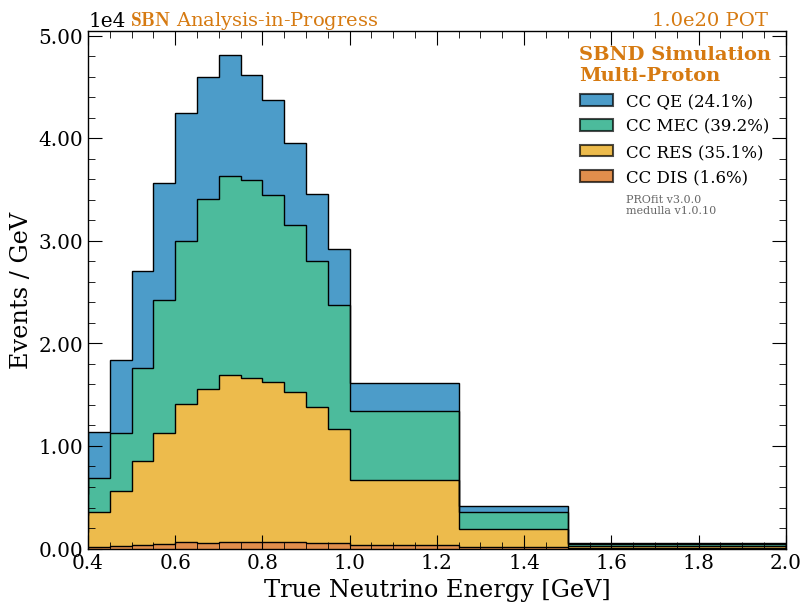

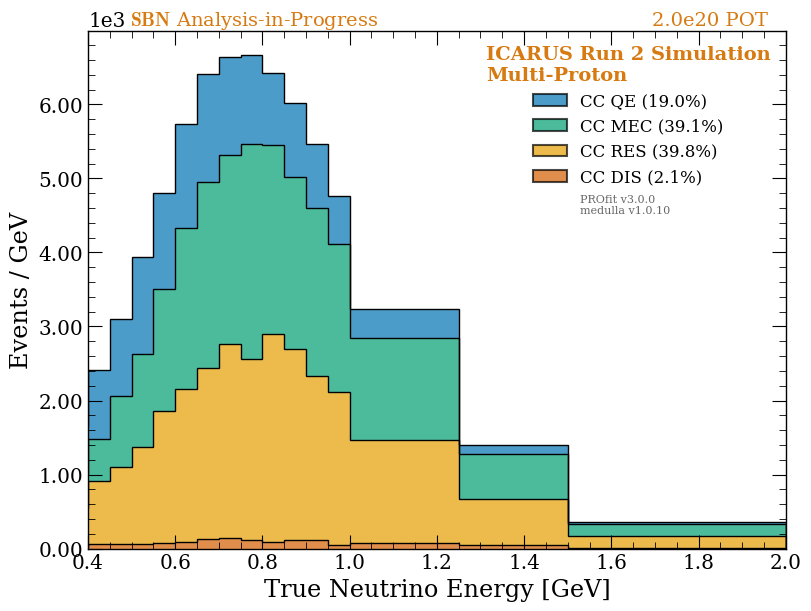

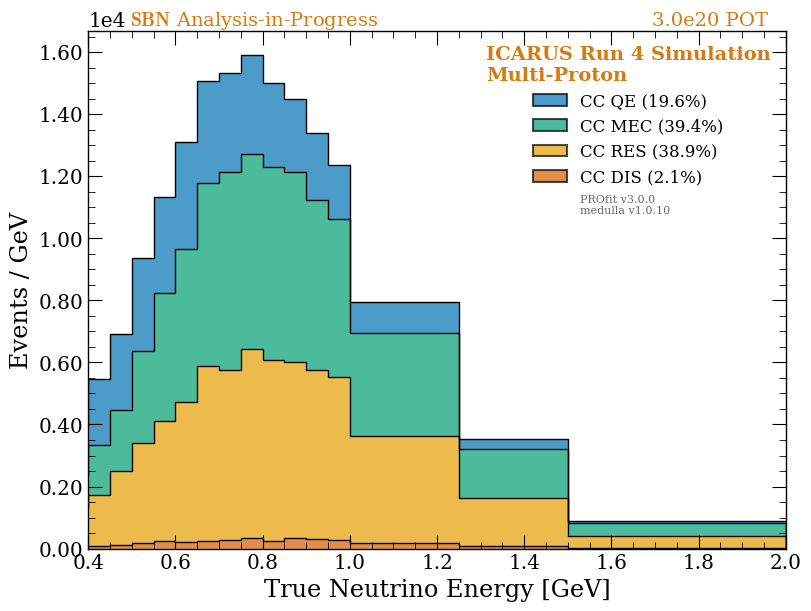

In [3]:
INPUT_FILE = INPUT / f'signal_inclusive_v1_PROplot_histograms.root'

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['CC QE', 'CC MEC', 'CC RES', 'CC DIS']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 3
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [0]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [1]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [2]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'
"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/inclusive_signal_bymode_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/inclusive_signal_bymode_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/inclusive_signal_bymode_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )

INPUT_FILE = INPUT / f'signal_exclusive_v1_PROplot_histograms.root'

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['CC QE', 'CC MEC', 'CC RES', 'CC DIS']
channels = ['Single-Proton', 'Multi-Proton']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 3
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [0]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [1]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [2]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'

"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_signal_bymode_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_signal_bymode_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_signal_bymode_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['CC QE', 'CC MEC', 'CC RES', 'CC DIS']
channels = ['Single-Proton', 'Multi-Proton']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 3
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [0]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [1]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [2]
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'
"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_signal_bymode_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_signal_bymode_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_signal_bymode_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )

Renamed /Users/mueller/Projects/spineosc/figures/hist_0_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_selected_byfs_sbnd.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_1_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_selected_byfs_icarus_run2.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_2_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/inclusive_selected_byfs_icarus_run4.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_0_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/exclusive_ccqe_selected_byfs_sbnd.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_1_0_v3.0.0.pdf to /Users/mueller/Projects/spineosc_technote/figures/signal_and_selection/exclusive_ccqe_selected_byfs_icarus_run2.pdf
Renamed /Users/mueller/Projects/spineosc/figures/hist_2_0_v3.0.0.pdf to /Users/mueller/Pr

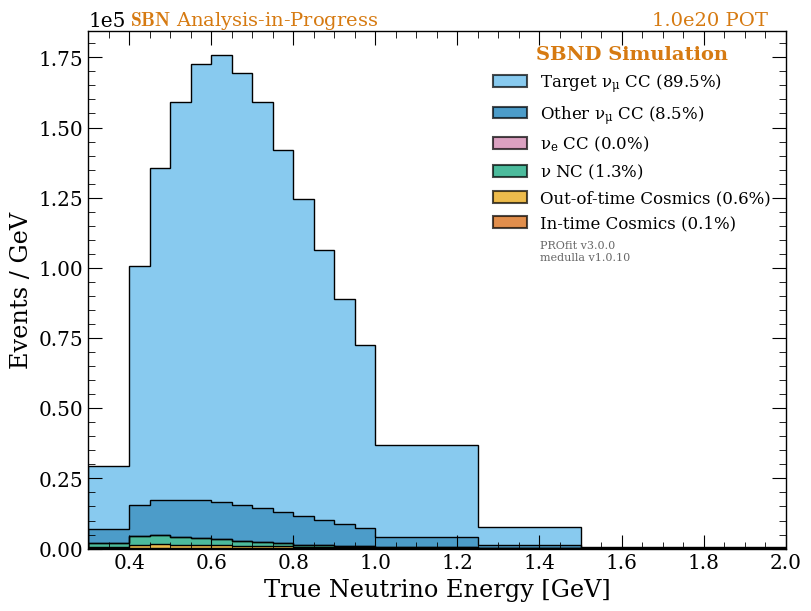

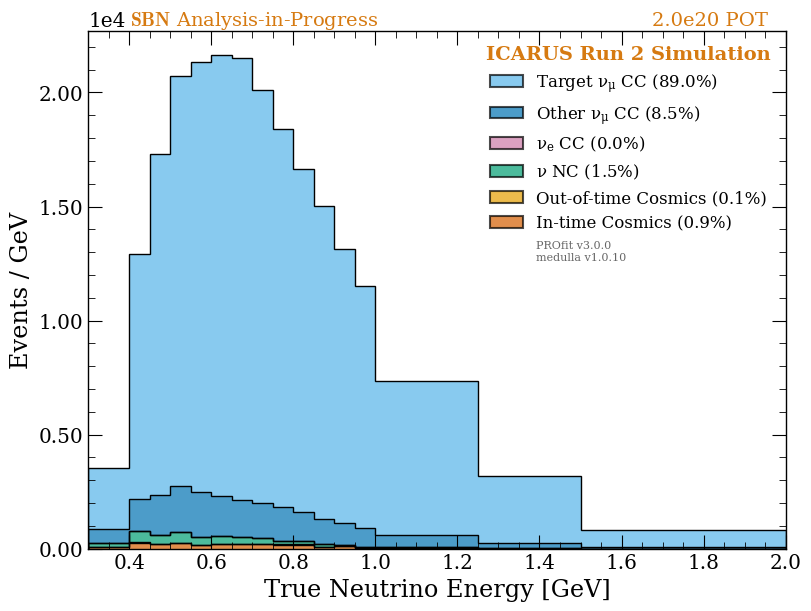

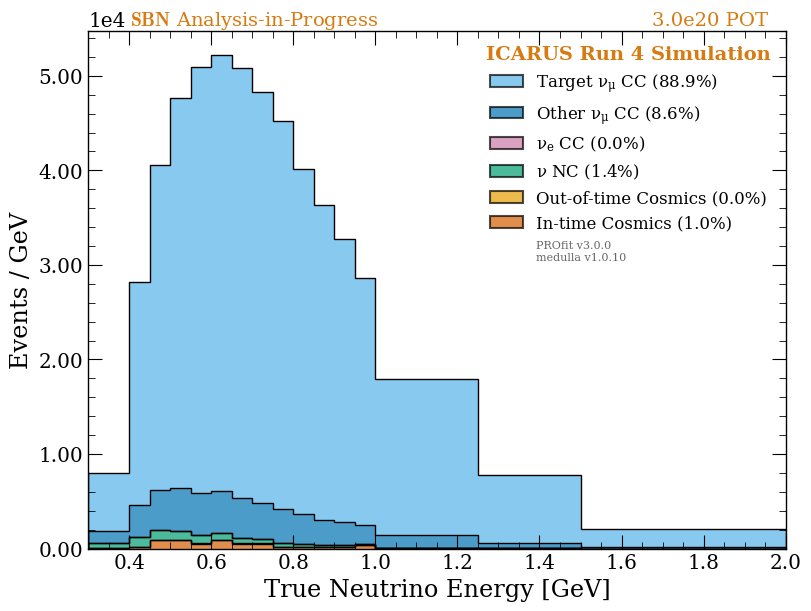

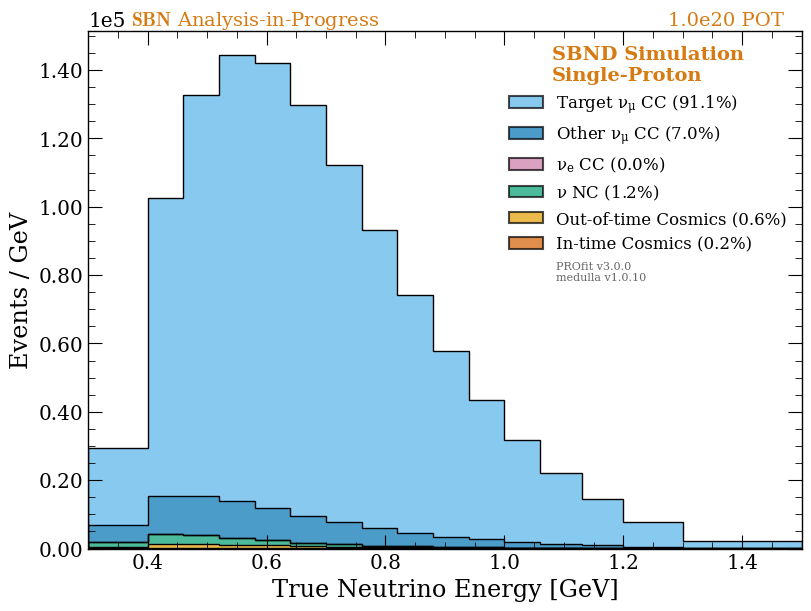

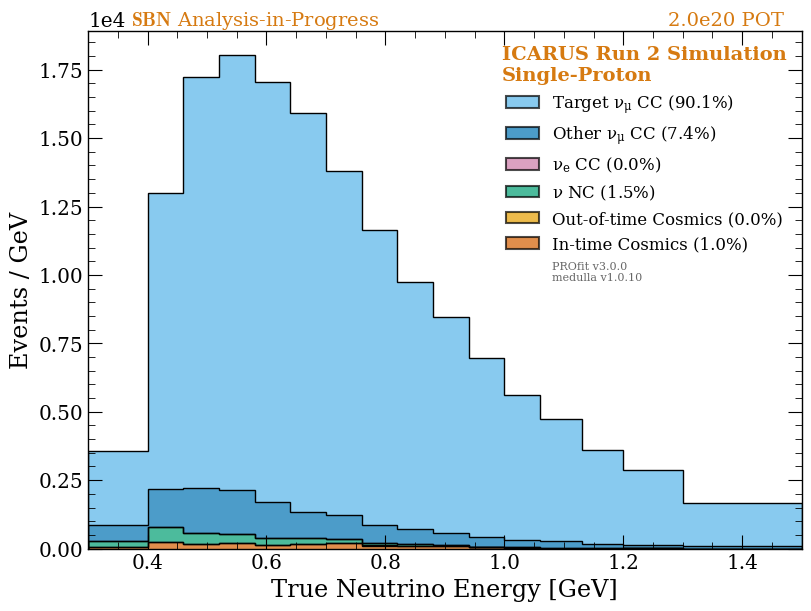

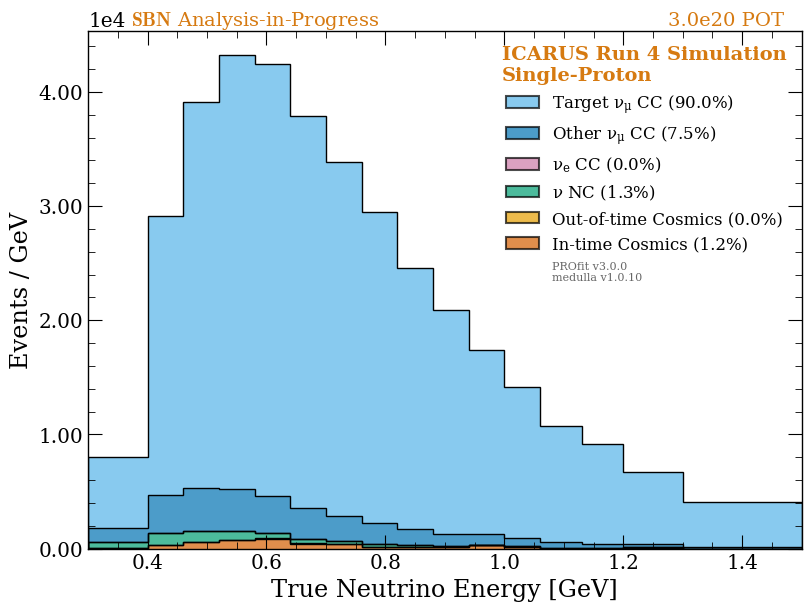

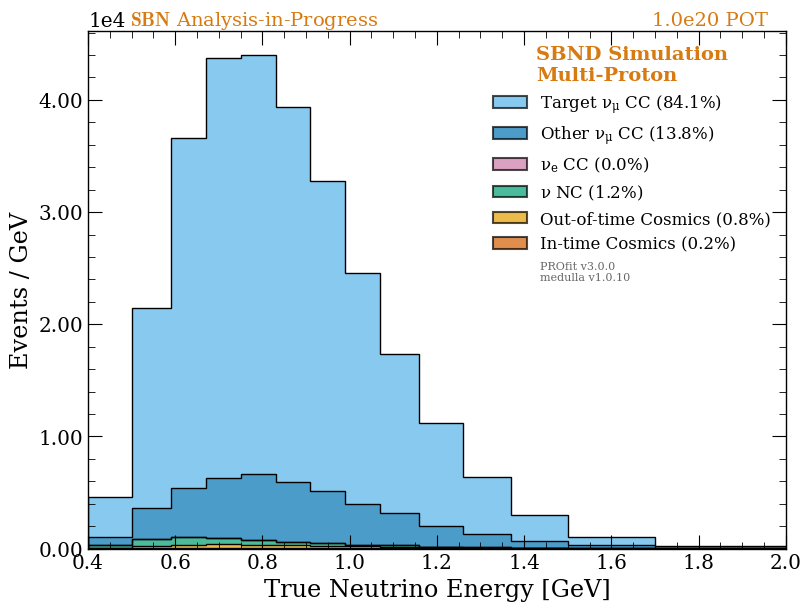

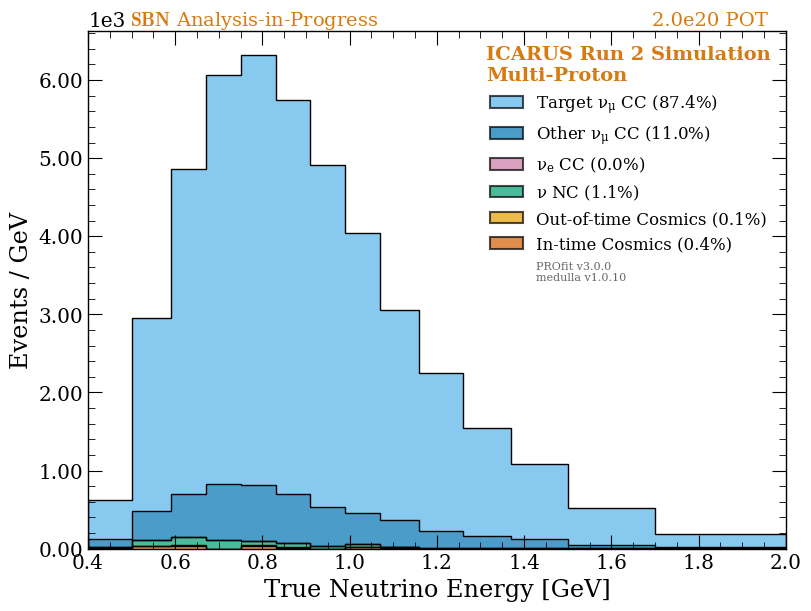

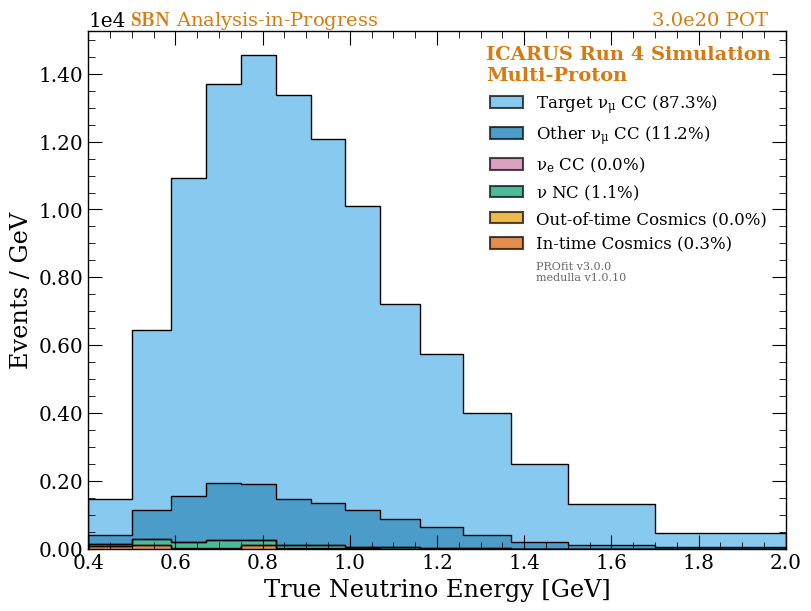

In [4]:
INPUT_FILE = INPUT / f'selected_inclusive_v1_PROplot_histograms.root'

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['Target $\nu_\mu$ CC', 'Other $\nu_\mu$ CC', '$\nu_e$ CC', '$\nu$ NC', 'Out-of-time Cosmics', 'In-time Cosmics']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 0
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [0]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [1]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [2]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'
"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/inclusive_selected_byfs_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/inclusive_selected_byfs_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/inclusive_selected_byfs_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )

INPUT_FILE = INPUT / f'selected_exclusive_v1_PROplot_histograms.root'

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['Target $\nu_\mu$ CC', 'Other $\nu_\mu$ CC', '$\nu_e$ CC', '$\nu$ NC', 'Out-of-time Cosmics', 'In-time Cosmics']
channels = ['Single-Proton', 'Multi-Proton']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 0
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [0]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [1]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 0
detectors = [2]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.3, 1.5]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'
"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_selected_byfs_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_selected_byfs_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/exclusive_ccqe_selected_byfs_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )

cfg = rf"""
[general]
input = '{str(INPUT_FILE)}'
output = '{str(OUTPUT)}'
code_version = 'v3.0.0'
selection_version = 'v1.0.10'
subchannels = ['Target $\nu_\mu$ CC', 'Other $\nu_\mu$ CC', '$\nu_e$ CC', '$\nu$ NC', 'Out-of-time Cosmics', 'In-time Cosmics']
channels = ['Single-Proton', 'Multi-Proton']
detectors = ['SBND Simulation', 'ICARUS Run 2 Simulation', 'ICARUS Run 4 Simulation']
counter_index = 0
savefig = true

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [0]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '1.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [1]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '2.0e20 POT'

[[plot]]
type = 'histogram'
variable = 0
channel = 1
detectors = [2]
colors = ['C0', 'C1', 'C2', 'C4', 'C3', 'C5']
xlabel = 'True Neutrino Energy [GeV]'
ylabel = 'Events / GeV'
xlim = [0.4, 2.0]
watermark = '$\bf{{SBN}}$ Analysis-in-Progress'
disable_systematics = true
counter_fmt = '.1%'
scale_by_width = 'enabled'
right_watermark = '3.0e20 POT'
"""

run(cfg)

if WRITE:
    map = {
        'hist_0_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_selected_byfs_sbnd.pdf',
        'hist_1_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_selected_byfs_icarus_run2.pdf',
        'hist_2_0_v3.0.0.pdf': 'signal_and_selection/exclusive_multiproton_selected_byfs_icarus_run4.pdf',
    }
    map_file(
        figure_directory=TECHNOTE,
        out=OUTPUT,
        map=map
    )